In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import binary_dilation
import pandas as pd
from pathlib import Path


from common import hallmark as hm
from common import mockservation as mk
from common import io_raptor as io
from common import dalt
from common import viz

from plotscripts import getimagedata, subtract
from plotscripts import *
from module import import_ab
from inter import *

In [2]:
# Parameters
n_pix = 1000
FoV  = 40 # uas
pixel_scale = FoV / n_pix  

In [3]:
# Grid generation

a    = FoV * ((np.arange(n_pix) + 0.5) / n_pix - 0.5)
b    = FoV * ((np.arange(n_pix) + 0.5) / n_pix - 0.5)
A, B = np.meshgrid(a, b)

### Test run

#### Load multiple image with Pandas

In [4]:
pf = hm.ParaFrame('cache/{mag}a{aspin:g}_w{window:d}/Rh{Rhigh:d}_i{inc:d}/n{n:n}/img_data_{snapshot:d}.h5')
sel = pf(snapshot=[999, 1000])
display(sel)

,path,mag,aspin,window,Rhigh,inc,n,snapshot
1,cache/Ma101_w1/Rh1_i15/n0/img_data_999.h5,M,101.0,1,1,15,0,999
2,cache/Ma101_w1/Rh1_i15/n1/img_data_1000.h5,M,101.0,1,1,15,1,1000
6,cache/Ma101_w1/Rh1_i15/n1/img_data_999.h5,M,101.0,1,1,15,1,999
8,cache/Ma101_w1/Rh1_i15/n100/img_data_999.h5,M,101.0,1,1,15,100,999
9,cache/Ma101_w1/Rh1_i15/n2/img_data_1000.h5,M,101.0,1,1,15,2,1000
13,cache/Ma101_w1/Rh1_i15/n2/img_data_999.h5,M,101.0,1,1,15,2,999
16,cache/Ma101_w1/Rh1_i30/n0/img_data_999.h5,M,101.0,1,1,30,0,999
17,cache/Ma101_w1/Rh1_i30/n1/img_data_1000.h5,M,101.0,1,1,30,1,1000
21,cache/Ma101_w1/Rh1_i30/n1/img_data_999.h5,M,101.0,1,1,30,1,999
23,cache/Ma101_w1/Rh1_i30/n100/img_data_999.h5,M,101.0,1,1,30,100,999


In [5]:
inc = 15
n = 1
snap = 1000 #999 for avegared from sum i=0 ^ n, 1000 for isolated
s = sel[(sel['inc'] == inc) & (sel['n'] == n) &(sel['snapshot'] == snap) ]

if s.path.shape == (1,): 
    path_object = Path(s.path.item())
    img_path = str(path_object.parent)
    _, _, _, Img = getimagedata(img_path, snap)
    
else : 
    print('More than one image found')

Reading in:  cache/Ma101_w1/Rh1_i15/n1/img_data_1000.h5
8


#### Manually load a image

In [25]:
inc = 60
img_path = f"cache/Ma101_w1/Rh1_i{inc}"
_, _, _, Img = subtract(img_path+"/n100", img_path+"/n0", 999 , ave=False)
# data_id_all, min, max, Img = getimagedata(img_path+'/n0', 1000)


read from cache/Ma101_w1/Rh1_i60/n100 and cache/Ma101_w1/Rh1_i60/n0
Reading in:  cache/Ma101_w1/Rh1_i60/n100/img_data_999.h5
8
Reading in:  cache/Ma101_w1/Rh1_i60/n0/img_data_999.h5
8
Reading in:  cache/Ma101_w1/Rh1_i60/n100/img_data_1000.h5
8


#### Check loaded image (with critical curve)

In [6]:
#get critical curve 
alpha1, beta1 = import_ab(1.01, inc, True) 

# critical curve in r, phi
R = np.sqrt(alpha1**2 + beta1**2)
PHI = np.arctan2(beta1, alpha1) 
alpha = np.round((alpha1 / pixel_scale + 0.5) * n_pix).astype(int)
beta = np.round((beta1 / pixel_scale + 0.5) * n_pix).astype(int)

def f(phi):
    
    # print(f'In shape {phi.shape}')
    R_ref = np.sqrt(alpha1**2 + beta1**2)
    
    phi       = np.mod(phi + np.pi, 2*np.pi) - np.pi
    PHI_ref   = np.mod(PHI + np.pi, 2*np.pi) - np.pi

    inds=[]
    for p in phi:
        dPHI = np.abs(PHI_ref - p)
        ind = np.nanargmin(dPHI) 
        inds.append(ind)
     
    inds = np.array(inds)
   
    phi_new = PHI_ref[inds]
    r_new = R_ref[inds]
    
    # print(f'Out PHI shape {phi_new.shape}')
    # print(f'Out R shape {r_new.shape}')

    return r_new, phi_new

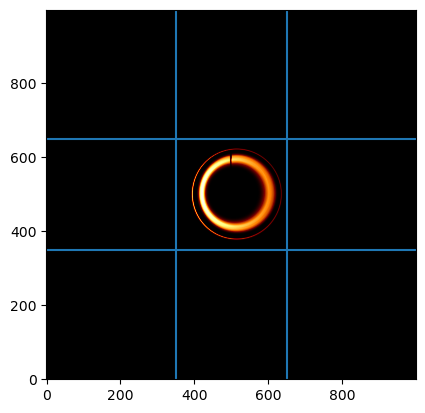

In [7]:
plt.imshow((Img/np.max(Img))**0.5, vmin=0.0, vmax=1.0, cmap='afmhot', origin='lower')
#            , extent=[-20,20,-20,20])
# plt.plot(alpha1, beta1, color='cyan', linewidth=1.5, label='Critical Curve')
xmin, xmax = 350, 650
ymin, ymax = 350, 650

plt.axvline(xmin)
plt.axvline(xmax)
plt.axhline(ymin)
plt.axhline(ymax)


We only focus on centeral region where photon rings are located. Setting limit in image indices and cut out other info(change boundary accordingly.).

In [8]:
Img_c  = Img[ymin:ymax, xmin:xmax]
A_c    = A[ymin:ymax, xmin:xmax]
B_c    = B[ymin:ymax, xmin:xmax]

alpha_min = FoV * ((xmin + 0.5) / n_pix - 0.5)
alpha_max = FoV * ((xmax - 0.5) / n_pix - 0.5)
beta_min  = FoV * ((ymin + 0.5) / n_pix - 0.5)
beta_max  = FoV * ((ymax - 0.5) / n_pix - 0.5)
extent=[alpha_min, alpha_max, beta_min, beta_max]
print(extent)
print(Img_c.shape)

[-5.98, 5.979999999999999, -5.98, 5.979999999999999]
(300, 300)


Convert pixels into distorted polar coordinate defined with critical curve. 

In [9]:
r_pix = np.sqrt(( A_c**2 + B_c**2 ))
phi_pix = np.arctan2(B_c,A_c)

phi_flat = phi_pix.ravel()
r_out, phi_out = f(phi_flat)

r_crit = r_out.reshape(phi_pix.shape)
phi_crit = phi_out.reshape(phi_pix.shape)

### Mask& interpolate

Define mask condition of r and phi to pick pixels to update with interpolated data. 

In [10]:
#mask r
r_mask_1 = (r_pix < 0.86 * r_crit) & (r_pix > 0.69 * r_crit)
# r_mask_2 = (r_pix < 0.99 * r_crit) & (r_pix > 0.83 * r_crit)
# r_mask = (r_pix < 4.2) & (r_pix > 3.2)

#mask phi 
phi_c = np.pi/2
phi_mask_1 =  ( phi_pix > 0.97 *phi_c) & ( phi_pix < 1.06*phi_c )
# phi_mask_2 =  (-phi_pix > 0.93 *phi_c) & (-phi_pix < 1.08*phi_c )
# phi_mask =  (np.abs(phi_pix) > 0.94*phi_c ) & (np.abs(phi_pix) < 1.13*phi_c )

mask_good = (Img_c > 0.5e16) 
mask_bad_1  = (~mask_good) & r_mask_1 & phi_mask_1
# mask_bad_2  = (~mask_good) & r_mask_2 & phi_mask_2
# mask_bad  = (~mask_good) & r_mask & phi_mask

In [11]:
i_good, j_good = np.nonzero(mask_good)
Img_good = Img_c[(i_good, j_good)]
print(Img_good.shape)

(11964,)


In [12]:
phi_good = np.arctan2(b[i_good], a[j_good])  # double check convention
r_good   = np.sqrt(( a[j_good] * a[j_good] + b[i_good] * b[i_good] )) /f(phi_good)[0]

In [13]:
# i_bad,  j_bad  = np.nonzero(mask_bad)
# Img_bad = Img_c[(i_bad, j_bad)]


i_bad_1,  j_bad_1  = np.nonzero(mask_bad_1)
Img_bad_1 = Img_c[(i_bad_1, j_bad_1)]
print(f"Bad 1 {Img_bad_1.shape}")

# i_bad_2,  j_bad_2  = np.nonzero(mask_bad_2)
# Img_bad_2 = Img_c[(i_bad_2, j_bad_2)]
# print(f"Bad 2 {Img_bad_2.shape}")

Bad 1 (83,)


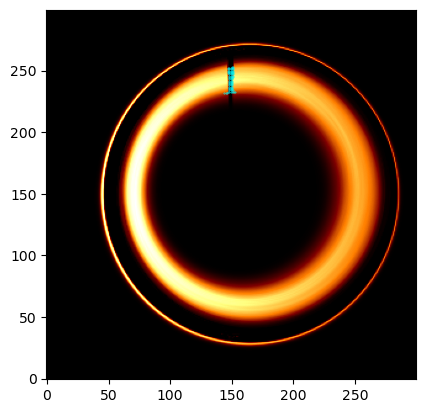

In [14]:
plt.scatter(j_bad_1 ,i_bad_1, s=0.1, color='cyan')
# plt.scatter(j_bad_2 ,i_bad_2, s=0.1, color='pink')
plt.imshow(Img_c**0.4, cmap='afmhot', origin='lower')

In [15]:
#expand boundary 
def expand(mask_bad, i_bad, j_bad): 
    dilated_bad  = binary_dilation(mask_bad, structure=np.ones((5, 5)))
    edge_mask = dilated_bad & ~mask_bad
    adjacent_values = Img_c[edge_mask]
    i_edge, j_edge = np.nonzero(edge_mask)
    
    coords_bad = np.column_stack((i_bad, j_bad))
    coords_edge = np.column_stack((i_edge, j_edge))
    coords_combined = np.vstack([coords_bad, coords_edge])
    coords_unique = np.unique(coords_combined, axis=0)
    
    i_bad, j_bad = coords_unique[:, 0], coords_unique[:, 1]
    
    Img_bad = Img[i_bad, j_bad]
    print(i_bad.shape, j_bad.shape)

    phi_bad = np.arctan2(b[i_bad], a[j_bad])  # double check convention
    r_bad   = np.sqrt(( a[j_bad] * a[j_bad] + b[i_bad] * b[i_bad] )) / f(phi_bad)[0]
    print(f"Img shape {Img_good.shape}")
    print(f"Good points shape {r_good.shape}, {phi_good.shape}")
    print(f"Bad points shape {r_bad.shape}, {phi_bad.shape}")
    return Img_bad, phi_bad, r_bad, i_bad, j_bad

In [16]:
Img_bad_1, phi_bad_1, r_bad_1, i_bad_1, j_bad_1 = expand(mask_bad_1, i_bad_1, j_bad_1)
# Img_bad_2, phi_bad_2, r_bad_2, i_bad_2, j_bad_2 = expand(mask_bad_2, i_bad_2, j_bad_2)

(235,) (235,)
Img shape (11964,)
Good points shape (11964,), (11964,)
Bad points shape (235,), (235,)


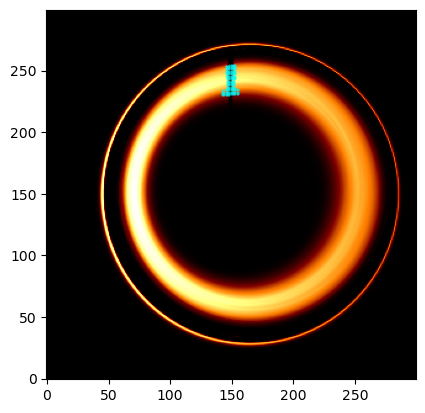

In [17]:
plt.scatter(j_bad_1 ,i_bad_1, s=0.1, color='cyan')
# plt.scatter(j_bad_2 ,i_bad_2, s=0.1, color='pink')
plt.imshow(Img_c**0.4, cmap='afmhot', origin='lower')

In [18]:
Img_fill_1 = scipy.interpolate.griddata((r_good, phi_good), Img_good, (r_bad_1, phi_bad_1), fill_value=0.0, method='linear')
# Img_fill_2 = scipy.interpolate.griddata((r_good, phi_good), Img_good, (r_bad_2, phi_bad_2), fill_value=0.0, method='linear')

print(Img_fill_1.shape)
# print(Img_fill_2.shape)

(235,)


In [19]:
Img_fixed = Img_c.copy()
Img_fixed[(i_bad_1, j_bad_1)] = Img_fill_1
# Img_fixed[(i_bad_2, j_bad_2)] = Img_fill_2

In [20]:
Img[ymin:ymax, xmin:xmax] = Img_fixed

<Figure size 1000x1000 with 0 Axes>

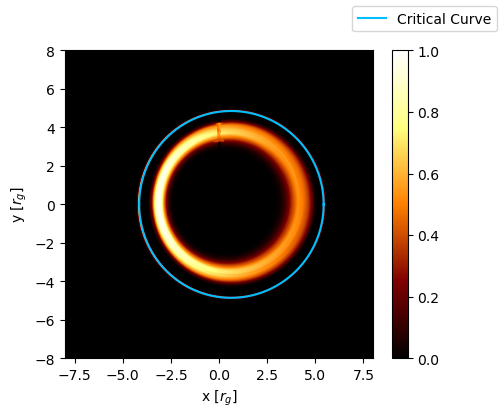

In [21]:
plt.figure(figsize=(10,10),facecolor='w')
fig, ax = plt.subplots(1,1,figsize=(5,4), sharex=True, sharey=True)

figure = ax.imshow((Img/np.max(Img))**0.5, cmap='afmhot', origin='lower', extent=[-20,20,-20,20])
# plt.scatter(0,-4, s=30, color='blue')
ax.plot(alpha1, beta1, color='deepskyblue', linewidth=1.5, label='Critical Curve')

# connect edge
# alpha_closed = np.r_[alpha1[0:200000], alpha1[1]]
# beta_closed =  np.r_[beta1[0:200000], beta1[1]] 
# plot connecting line 
# ax.plot(alpha_closed, beta_closed, linewidth=1, color='deepskyblue', linestyle='--')

ax.set_xlim(-8,8)
ax.set_ylim(-8,8)
ax.set_xlabel(r"x [$r_g$]")
ax.set_ylabel(r"y [$r_g$]")

fig.colorbar(figure, ax=ax)

fig.legend()
fig.savefig(f'output/i60_hpr_img_data_0.png')
# fig.savefig(f'output/i{inc}_hpr_img_data_0.png')

In [22]:
print(np.max(Img), np.min(Img))
Img.shape

3.5365213378732492e+16 0.0


(1000, 1000)

In [23]:
def writehdf5(img_path, img_new, img_template, snap):  
    keys = list(img_template.keys())
    
    output_file = os.path.join(img_path, f'img_data_10{snap}.h5')
    if os.path.exists(output_file):
        os.remove(output_file)

    with h5py.File(output_file, 'w') as f_out:
        for key in keys:
            if key == keys[0]:
                f_out.create_dataset(key, data=img_new.astype(np.float64))
            else:
                f_out.create_dataset(key, data=img_template[key][()])
                
            for attr_name, attr_val in img_template[key].attrs.items():
                f_out[key].attrs[attr_name] = attr_val

        for attr_name, attr_val in img_template.attrs.items():
            f_out.attrs[attr_name] = attr_val

    return output_file

In [24]:
import rapplot

# get template
data_id = rapplot.read_data_id(img_path, snap)
min, max, image = rapplot.read_data(img_path, snap, data_id)

Reading in:  cache/Ma101_w1/Rh1_i15/n1/img_data_1000.h5
8


In [25]:
path = writehdf5(img_path, Img, image, snap)
print(path)

cache/Ma101_w1/Rh1_i15/n1/img_data_101000.h5


In [26]:
import h5py
from astropy import units
from astropy import constants as c

def image2d(image, stokes_ind, data_id):
    """Create 2D array of one of the Stokes parameters for plotting."""

    n_box = len(image[data_id[stokes_ind]])              #depends on camera pixles you chose for GRRT   
    n_pixel_per_box = len(image[data_id[stokes_ind]][0]) #100
    pixels = int(np.sqrt(n_pixel_per_box))  # pixels per block side 10x10 

    n_blocks_side = int(round(np.sqrt(n_box)))
    
    # Total image dimensions
    width = n_blocks_side * pixels
    height = (n_box // n_blocks_side) * pixels

    image_array = np.zeros((height, width), dtype=float)

    for i in range(n_box):
        block_row = i // n_blocks_side
        block_col = i % n_blocks_side
        block_data = np.array(image[data_id[stokes_ind]][i])
        array = np.reshape(block_data, (pixels, pixels))
        image_array[
            block_row*pixels:(block_row+1)*pixels,
            block_col*pixels:(block_col+1)*pixels
        ] = array
        

    return image_array

def load_hdf5(f, snapshot, resize=False, **kwargs):

    data_id = list(f.keys())

    # MBH = (4.14e6 * units.M_sun).to(units.M_sun, equivalencies=s.GR)
    # dist = 8.127 * units.kpc
    # freq = 230 * units.GHz
    # rg = (c.G * MBH /c.c**2 )
    # Tunit = rg/c.c
    # mas = (rg/dist)* 206264.806*1000.
    # time = (int(snapshot) *10. *Tunit).to(units.s, equivalencies=s.GR)    
    
    stokes_ind = 0
    if resize: 
        img = image2d(f, stokes_ind, data_id)
    else: 
        if isinstance(f, h5py.File):
            img = f[data_id[0]][()]
            print(img.shape)

    halfrange =20
    # print(halfrange*2, halfrange*2)
    width, height = halfrange*2, halfrange*2
    return img


In [27]:
f = path
ind = 100000+snap

if isinstance(f, h5py.File):
    f = load_hdf5(f, ind, resize=False)
    print('here')
with h5py.File(f, "r") as g:
    f =  load_hdf5(g, ind, resize=False)

(1000, 1000)


In [29]:
#  test writing func

ind = 100000+snap
data_id = rapplot.read_data_id(img_path, ind)
min, max, image = rapplot.read_data(img_path, ind, data_id)

if isinstance(image, h5py.File):
    keys = list(image.keys())
    im = image[keys[0]][()]  # read the first dataset as NumPy array


Reading in:  cache/Ma101_w1/Rh1_i15/n1/img_data_101000.h5
8


3.5365213378732492e+16 0.0


(-8.0, 8.0)

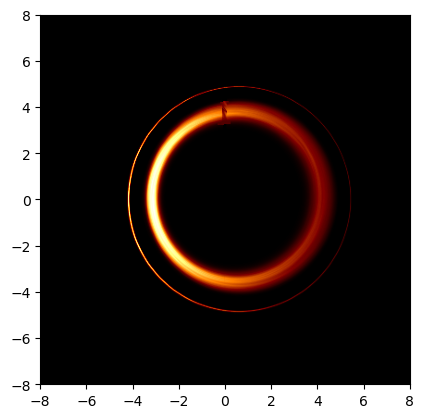

In [30]:
plt.imshow(im, cmap='afmhot', origin='lower', extent=[-20,20,-20,20])
print(np.max(im), np.min(im))

plt.xlim(-8,8)
plt.ylim(-8,8)

In [ ]:
im.shape

### test module 

In [24]:
alpha, beta, R, PHI= curve(FoV, n_pix, a=1.01, inc=60)